# 01 - Data Exploration

## Objetivo general
El objetivo de este notebook fue realizar una exploración inicial del dataset final obtenido desde SQL Server, con el fin de validar su estructura, comprobar la integridad de la exportación, revisar la calidad de los datos, identificar valores faltantes, confirmar la distribución de la variable objetivo y dejar correctamente preparados los tipos de datos para fases posteriores de limpieza y modelado.

## Proyecto
Predicción de Riesgo de Lesión Renal Aguda (AKI)


### 1. Importar librerías
Se importaron las librerías principales para análisis de datos y visualización:

- `pandas` para manipulación de datos tabulares
- `numpy` para operaciones numéricas
- `matplotlib` y `seaborn` para visualización

Además, se configuró la visualización de pandas para mostrar todas las columnas y un mayor número de filas, facilitando la inspección del dataset.

In [2]:
import sys
!{sys.executable} -m pip install matplotlib seaborn pandas numpy scikit-learn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
FIGURES_DIR = "../figures"
RESULTS_DIR = "../results"

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Carpetas de figures y results listas.")

Carpetas de figures y results listas.


In [4]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

### 2. Carga del Dataset y definicón de columnas
Se definió manualmente la lista correcta de nombres de columnas del CSV, basándose en el orden real del `SELECT` final de la query en SQL Server.

Durante este paso se detectó que:
- el archivo no incluía cabecera
- el separador del archivo era `;`
- inicialmente faltaba una columna en la lista de nombres (`BaselineCreatinina`), lo que provocaba desalineación

Una vez corregido el orden y el número de columnas, el dataset fue cargado correctamente con:
- 1175 filas
- 24 columnas

En esta fase se decidió cargar inicialmente el archivo como texto para poder controlar manualmente la conversión posterior de tipos.


In [9]:
import pandas as pd

columnas = [
    "IdIngreso",
    "UUIdPaciente",
    "Sexo",
    "EdadAproxIngreso",
    "FechaIngreso",
    "FechaAlta",
    "IdHospital",
    "IdSociedad",
    "IdDoctor",
    "PrimeraFechaLab",
    "Creatinina_mg_dL",
    "Urea_mg_dL",
    "Potasio_mmol_L",
    "Sodio_mmol_L",
    "BaselineFecha",
    "BaselineCreatinina",
    "MaxCreatinina48h",
    "AKI_48h",
    "AINE",
    "IECA",
    "ARAII",
    "DIURETICO",
    "VANCOMICINA",
    "AMINOGLUCOSIDO"
]

file_path = "C:/Users/isabe/OneDrive/Desktop/Resultados_SQL_TFG.csv"

# Cargar todo como texto para controlar la conversión manualmente
df = pd.read_csv(
    file_path,
    sep=";",
    header=None,
    names=columnas,
    index_col=False,
    dtype=str
)

# =========================
# Conversión de variables
# =========================

date_cols = ["FechaIngreso", "FechaAlta", "PrimeraFechaLab", "BaselineFecha"]

float_cols = [
    "Creatinina_mg_dL",
    "Urea_mg_dL",
    "Potasio_mmol_L",
    "Sodio_mmol_L",
    "BaselineCreatinina",
    "MaxCreatinina48h"
]

int_feature_cols = [
    "EdadAproxIngreso",
    "Sexo",
    "AINE",
    "IECA",
    "ARAII",
    "DIURETICO",
    "VANCOMICINA",
    "AMINOGLUCOSIDO"
]

# Fechas
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Numéricas con coma decimal
for col in float_cols:
    df[col] = (
        df[col]
        .str.strip()
        .str.replace(",", ".", regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Enteras / binarias
for col in int_feature_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

print("Dataset cargado correctamente.")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

df.head()

Dataset cargado correctamente.
Filas: 1175
Columnas: 24


,IdIngreso,UUIdPaciente,Sexo,EdadAproxIngreso,FechaIngreso,FechaAlta,IdHospital,IdSociedad,IdDoctor,PrimeraFechaLab,Creatinina_mg_dL,Urea_mg_dL,Potasio_mmol_L,Sodio_mmol_L,BaselineFecha,BaselineCreatinina,MaxCreatinina48h,AKI_48h,AINE,IECA,ARAII,DIURETICO,VANCOMICINA,AMINOGLUCOSIDO
0,1417285,704AAA68-9DF8-40E8-8D49-A9542E0B83A2,1,61,2024-08-01,2024-08-02,46,5510,10102,2024-08-01,0.96,46.5,4.83,144.0,2024-08-01,0.96,NaN,0,0,0,0,0,0,0
1,1417327,F329617D-6F0E-4F4F-9D59-C792B410137F,1,46,2024-08-01,2024-08-02,46,5510,10102,2024-08-01,1.15,40.0,4.41,142.0,2024-08-01,1.15,NaN,0,0,0,0,0,0,0
2,1417344,D6696588-A427-4550-94FE-F010285AD364,2,25,2024-08-01,2024-08-02,46,5527,11506,2024-08-01,0.75,18.1,4.09,138.0,2024-08-01,0.75,NaN,0,1,0,0,0,0,0
3,1418498,52088A9A-19EA-4833-A361-4E633B158A6E,1,78,2024-08-07,2024-08-08,46,5510,10102,2024-08-07,0.97,27.9,4.70,143.0,2024-08-07,0.97,NaN,0,0,0,0,0,0,0
4,1418503,29882E34-80B7-4171-8C35-2514BD767159,2,35,2024-08-07,2024-08-07,46,449,10102,2024-08-07,0.63,55.6,4.43,140.0,2024-08-07,0.63,NaN,0,0,0,0,0,0,0


### 3. Vista general del dataset
Se inspeccionaron las primeras filas del dataset utilizando:
- `head()`
- `sample()`
- listado de nombres de columnas

Esto permitió confirmar visualmente:
- que la carga estaba alineada correctamente
- que cada columna parecía contener el tipo de dato esperado
- que la estructura del archivo coincidía con la lógica definida en la query SQL


In [10]:
df.head()
df.sample(5, random_state=42)

,IdIngreso,UUIdPaciente,Sexo,EdadAproxIngreso,FechaIngreso,FechaAlta,IdHospital,IdSociedad,IdDoctor,PrimeraFechaLab,Creatinina_mg_dL,Urea_mg_dL,Potasio_mmol_L,Sodio_mmol_L,BaselineFecha,BaselineCreatinina,MaxCreatinina48h,AKI_48h,AINE,IECA,ARAII,DIURETICO,VANCOMICINA,AMINOGLUCOSIDO
661,1565738,0861FCB4-701F-4A18-9463-DFBE3D86B84B,2,110,2025-10-19,2025-10-21,55,2685,13440,2025-10-19 02:50:13,1.77,NaN,4.9,155.0,2025-10-19 02:50:13,1.77,NaN,0,0,0,0,0,0,0
427,1533231,A159883A-9973-4DFD-8DE5-D4BFCEBB66F2,2,84,2025-07-01,2025-07-04,55,2685,13440,2025-07-01 18:36:18,0.66,NaN,3.8,139.0,2025-07-01 18:36:18,0.66,0.66,0,0,0,0,1,0,0
192,1503026,EAE31BAC-C463-430F-AF92-305B09D21553,1,84,2025-04-06,2025-04-09,55,2685,13373,2025-04-06 19:42:37,2.65,NaN,3.7,163.0,2025-04-06 19:42:37,2.65,2.86,0,1,0,0,1,0,0
209,1505362,14D84FA3-79EA-42C9-BBD0-DF2E4F58FC7A,2,77,2025-04-11,2025-04-21,55,147,13415,2025-04-11 12:49:51,1.05,NaN,4.5,136.0,2025-04-11 12:49:51,1.05,NaN,0,1,0,0,0,0,0
738,1574438,CA947BCB-05E8-48BA-97DF-3B211906D786,2,101,2025-11-09,2025-11-13,55,2685,13410,2025-11-09 04:03:27,0.63,NaN,5.0,138.0,2025-11-09 04:03:27,0.63,0.66,0,1,0,0,1,0,0


In [11]:
df.columns.tolist()

['IdIngreso',
 'UUIdPaciente',
 'Sexo',
 'EdadAproxIngreso',
 'FechaIngreso',
 'FechaAlta',
 'IdHospital',
 'IdSociedad',
 'IdDoctor',
 'PrimeraFechaLab',
 'Creatinina_mg_dL',
 'Urea_mg_dL',
 'Potasio_mmol_L',
 'Sodio_mmol_L',
 'BaselineFecha',
 'BaselineCreatinina',
 'MaxCreatinina48h',
 'AKI_48h',
 'AINE',
 'IECA',
 'ARAII',
 'DIURETICO',
 'VANCOMICINA',
 'AMINOGLUCOSIDO']

### 4. Estructura incial y tipo de datos antes de la conversión 
Se utilizó `df.info()` para revisar:
- número total de filas
- número total de columnas
- tipo de dato de cada columna
- número de valores no nulos por variable

Este paso permitió comprobar que:
- las variables se habían cargado correctamente
- muchas columnas estaban todavía como texto (`str`)
- esto era esperable, dado que el CSV contenía fechas y números en formato texto


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1175 entries, 0 to 1174
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   IdIngreso           1175 non-null   str           
 1   UUIdPaciente        1175 non-null   str           
 2   Sexo                1175 non-null   Int64         
 3   EdadAproxIngreso    1175 non-null   Int64         
 4   FechaIngreso        1175 non-null   datetime64[us]
 5   FechaAlta           1150 non-null   datetime64[us]
 6   IdHospital          1175 non-null   str           
 7   IdSociedad          1175 non-null   str           
 8   IdDoctor            1175 non-null   str           
 9   PrimeraFechaLab     1175 non-null   datetime64[us]
 10  Creatinina_mg_dL    1170 non-null   float64       
 11  Urea_mg_dL          41 non-null     float64       
 12  Potasio_mmol_L      1122 non-null   float64       
 13  Sodio_mmol_L        1126 non-null   float64       
 14  Bas

### 5. Revisión de valores faltantes antes de la conversión
Se calculó el número absoluto y el porcentaje de valores nulos por columna.

Este análisis permitió identificar:
- variables prácticamente completas
- variables con algunos valores faltantes razonables, como `FechaAlta`
- variables analíticas con cantidades variables de missing
- una alta proporción de valores faltantes en `Urea_mg_dL`
- un número elevado de faltantes en `MaxCreatinina48h`, coherente con la ausencia de determinaciones dentro de la ventana de 48 horas en algunos ingresos

In [15]:
missing_values = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "n_missing": missing_values,
    "percent_missing": missing_percent
}).sort_values(by="percent_missing", ascending=False)

missing_summary

,n_missing,percent_missing
Urea_mg_dL,1134,96.51
MaxCreatinina48h,497,42.30
Potasio_mmol_L,53,4.51
Sodio_mmol_L,49,4.17
FechaAlta,25,2.13
Creatinina_mg_dL,5,0.43
BaselineFecha,2,0.17
BaselineCreatinina,2,0.17
IdSociedad,0,0.00
IdHospital,0,0.00


### 6. Revisión de duplicados 
Se comprobó la existencia de:
- duplicados completos del dataset
- duplicados específicos en `IdIngreso`

Los resultados mostraron:
- 0 duplicados completos
- 0 duplicados en `IdIngreso`

Esto confirmó que:
- cada fila representa un ingreso hospitalario único
- la unidad de análisis del estudio estaba correctamente definida como una fila por ingreso


In [16]:
print("Duplicados completos:", df.duplicated().sum())
print("Duplicados en IdIngreso:", df["IdIngreso"].duplicated().sum())

Duplicados completos: 0
Duplicados en IdIngreso: 0


### 7. Revisión de valores únicos en variables claves
Se revisaron los valores únicos y sus frecuencias en:
- `Sexo`
- `AKI_48h`
- `AINE`
- `IECA`
- `ARAII`
- `DIURETICO`
- `VANCOMICINA`
- `AMINOGLUCOSIDO`

Esto permitió confirmar que:
- `Sexo` estaba codificado como `1` y `2`
- `AKI_48h` estaba correctamente codificado como `0` y `1`
- las variables farmacológicas estaban codificadas como binarias (`0`/`1`)
- no había categorías inesperadas ni errores evidentes en estas variables

También se confirmó el fuerte desbalanceo de la variable objetivo:
- 1146 casos negativos
- 29 casos positivos


In [17]:
print("Sexo:")
print(df["Sexo"].value_counts(dropna=False))

print("\nAKI_48h:")
print(df["AKI_48h"].value_counts(dropna=False))

for col in ["AINE", "IECA", "ARAII", "DIURETICO", "VANCOMICINA", "AMINOGLUCOSIDO"]:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))

Sexo:
Sexo
2    648
1    527
Name: count, dtype: Int64

AKI_48h:
AKI_48h
0    1146
1      29
Name: count, dtype: Int64

AINE:
AINE
0    600
1    575
Name: count, dtype: Int64

IECA:
IECA
0    1074
1     101
Name: count, dtype: Int64

ARAII:
ARAII
0    1096
1      79
Name: count, dtype: Int64

DIURETICO:
DIURETICO
0    703
1    472
Name: count, dtype: Int64

VANCOMICINA:
VANCOMICINA
0    1152
1      23
Name: count, dtype: Int64

AMINOGLUCOSIDO:
AMINOGLUCOSIDO
0    1166
1       9
Name: count, dtype: Int64


### 8. Inspección manual de valores originales en variables analíticas 
Se inspeccionaron ejemplos de valores en:
- `Creatinina_mg_dL`
- `Urea_mg_dL`
- `Potasio_mmol_L`
- `Sodio_mmol_L`
- `BaselineCreatinina`
- `MaxCreatinina48h`

Este paso permitió observar que los valores aparecían numéricamente correctos una vez convertidos, lo que resultó útil para validar que las analíticas contenían magnitudes clínicamente plausibles.

Durante el proceso también se detectó que, en el CSV original, estas variables venían con coma decimal, lo cual requería una conversión explícita.

In [18]:
cols_problematicas = [
    "Creatinina_mg_dL",
    "Urea_mg_dL",
    "Potasio_mmol_L",
    "Sodio_mmol_L",
    "BaselineCreatinina",
    "MaxCreatinina48h"
]

for col in cols_problematicas:
    print(f"\n===== {col} =====")
    print(df[col].dropna().head(20).tolist())


===== Creatinina_mg_dL =====
[0.96, 1.15, 0.75, 0.97, 0.63, 0.78, 0.78, 0.87, 0.79, 0.5, 0.62, 0.7, 0.78, 1.79, 0.68, 1.06, 0.71, 0.79, 0.91, 0.7]

===== Urea_mg_dL =====
[46.5, 40.0, 18.1, 27.9, 55.6, 32.4, 16.7, 36.5, 24.7, 27.7, 22.8, 35.3, 96.0, 35.3, 25.5, 38.8, 49.6, 46.0, 51.1, 27.2]

===== Potasio_mmol_L =====
[4.83, 4.41, 4.09, 4.7, 4.43, 4.36, 4.33, 4.22, 4.03, 4.81, 4.43, 5.19, 4.98, 4.9, 4.65, 3.72, 4.35, 4.2, 4.8, 4.53]

===== Sodio_mmol_L =====
[144.0, 142.0, 138.0, 143.0, 140.0, 142.3, 143.0, 144.0, 143.0, 138.0, 139.0, 135.0, 142.0, 142.0, 139.0, 138.0, 142.0, 140.0, 136.0, 142.0]

===== BaselineCreatinina =====
[0.96, 1.15, 0.75, 0.97, 0.63, 0.78, 0.78, 0.87, 0.79, 0.5, 0.62, 0.7, 0.78, 1.79, 0.68, 1.06, 0.71, 0.79, 0.91, 0.7]

===== MaxCreatinina48h =====
[1.07, 0.77, 2.37, 1.22, 0.69, 2.5, 0.81, 1.08, 1.91, 1.2, 1.32, 0.9, 0.69, 0.74, 0.96, 0.63, 0.81, 0.64, 0.66, 0.9]


### 9. Clasificación lógica de las variables
Se clasificaron las columnas del dataset según su función:

- **Identificadores**: `IdIngreso`, `UUIdPaciente`, `IdHospital`, `IdSociedad`, `IdDoctor`
- **Fechas**: `FechaIngreso`, `FechaAlta`, `PrimeraFechaLab`, `BaselineFecha`
- **Numéricas continuas**: creatinina, urea, potasio, sodio, creatinina basal y máxima en 48 horas
- **Binarias/categóricas**: sexo, variable objetivo y medicaciones
- **Variable objetivo**: `AKI_48h`

Este paso fue importante para organizar el trabajo posterior y distinguir qué variables podían ser candidatas a modelado y cuáles no.


In [19]:
id_cols = ["IdIngreso", "UUIdPaciente", "IdHospital", "IdSociedad", "IdDoctor"]

date_cols = ["FechaIngreso", "FechaAlta", "PrimeraFechaLab", "BaselineFecha"]

numeric_cols = [
    "EdadAproxIngreso",
    "Creatinina_mg_dL",
    "Urea_mg_dL",
    "Potasio_mmol_L",
    "Sodio_mmol_L",
    "BaselineCreatinina",
    "MaxCreatinina48h"
]

binary_cols = [
    "Sexo",
    "AKI_48h",
    "AINE",
    "IECA",
    "ARAII",
    "DIURETICO",
    "VANCOMICINA",
    "AMINOGLUCOSIDO"
]

target_col = "AKI_48h"

### 10. Conversión de tipos de datos
Se realizó la conversión formal de tipos del dataset:

- las variables de fecha se convirtieron a `datetime`
- las variables numéricas continuas se convirtieron a `float`
- las variables enteras y binarias se convirtieron a tipo entero (`Int64`)

Durante este proceso se detectó un problema importante:
- las variables analíticas venían con coma decimal en el CSV, por ejemplo `0,96`
- una conversión directa con `pd.to_numeric()` generaba una gran cantidad de `NaN`

Para resolverlo, se aplicó:
- limpieza de espacios
- sustitución de `,` por `.`
- conversión posterior a numérico

También se corrigió un error inicial derivado de intentar aplicar operaciones de texto sobre columnas ya interpretadas como enteros, separando correctamente las columnas decimales de las enteras.


In [20]:
# Fechas
date_cols = ["FechaIngreso", "FechaAlta", "PrimeraFechaLab", "BaselineFecha"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Columnas con decimales que vienen como texto con coma
float_cols = [
    "Creatinina_mg_dL",
    "Urea_mg_dL",
    "Potasio_mmol_L",
    "Sodio_mmol_L",
    "BaselineCreatinina",
    "MaxCreatinina48h"
]

for col in float_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.replace(",", ".", regex=False)
        .replace("nan", pd.NA)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Columnas enteras
int_cols = [
    "IdIngreso",
    "Sexo",
    "EdadAproxIngreso",
    "IdHospital",
    "IdSociedad",
    "IdDoctor",
    "AKI_48h",
    "AINE",
    "IECA",
    "ARAII",
    "DIURETICO",
    "VANCOMICINA",
    "AMINOGLUCOSIDO"
]

for col in int_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

### 11. Verificación de estructura después de la conversión
Se volvió a ejecutar `df.info()` tras la conversión para comprobar que:
- las fechas estaban realmente como `datetime`
- las variables analíticas estaban como `float`
- las variables binarias y enteras estaban como enteros
- el dataset había quedado correctamente tipado

Este paso confirmó que la transformación de tipos se realizó correctamente.

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1175 entries, 0 to 1174
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   IdIngreso           1175 non-null   Int64         
 1   UUIdPaciente        1175 non-null   str           
 2   Sexo                1175 non-null   Int64         
 3   EdadAproxIngreso    1175 non-null   Int64         
 4   FechaIngreso        1175 non-null   datetime64[us]
 5   FechaAlta           1150 non-null   datetime64[us]
 6   IdHospital          1175 non-null   Int64         
 7   IdSociedad          1175 non-null   Int64         
 8   IdDoctor            1175 non-null   Int64         
 9   PrimeraFechaLab     1175 non-null   datetime64[us]
 10  Creatinina_mg_dL    1170 non-null   float64       
 11  Urea_mg_dL          41 non-null     float64       
 12  Potasio_mmol_L      1122 non-null   float64       
 13  Sodio_mmol_L        1126 non-null   float64       
 14  Bas

### 12. Revisión de valores faltantes después de la conversión
Se recalcularon los valores faltantes tras la conversión de tipos.

Esto permitió comprobar que:
- las columnas analíticas habían recuperado correctamente la mayor parte de sus valores tras resolver el problema de la coma decimal
- `Creatinina_mg_dL`, `Potasio_mmol_L`, `Sodio_mmol_L` y `BaselineCreatinina` presentaban niveles de completitud razonables
- `Urea_mg_dL` seguía mostrando una proporción extremadamente alta de nulos
- `MaxCreatinina48h` mantenía un número elevado de faltantes, coherente con la construcción clínica de la variable

In [31]:
missing_values = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "n_missing": missing_values,
    "percent_missing": missing_percent
}).sort_values(by="percent_missing", ascending=False)
missing_summary.to_csv(f"{RESULTS_DIR}/results_01_missing_summary.csv", index=True)
missing_summary

,n_missing,percent_missing
Urea_mg_dL,1134,96.51
MaxCreatinina48h,497,42.30
Potasio_mmol_L,53,4.51
Sodio_mmol_L,49,4.17
FechaAlta,25,2.13
Creatinina_mg_dL,5,0.43
BaselineFecha,2,0.17
BaselineCreatinina,2,0.17
IdSociedad,0,0.00
IdHospital,0,0.00


### 13. Distribución de la variable objetivo
Se analizó la distribución de `AKI_48h` mediante:
- conteo absoluto
- porcentaje de clases
- visualización con gráfico de barras

Esto confirmó de forma clara el fuerte desbalanceo del dataset:
- aproximadamente 97.5% de casos negativos
- aproximadamente 2.5% de casos positivos

Este hallazgo es metodológicamente muy relevante, ya que condiciona las decisiones posteriores sobre:
- partición estratificada
- manejo del desbalanceo
- elección de métricas de evaluación

In [23]:
print(df["AKI_48h"].value_counts(dropna=False))
print(df["AKI_48h"].value_counts(normalize=True, dropna=False) * 100)

AKI_48h
0    1146
1      29
Name: count, dtype: Int64
AKI_48h
0    97.531915
1     2.468085
Name: proportion, dtype: Float64


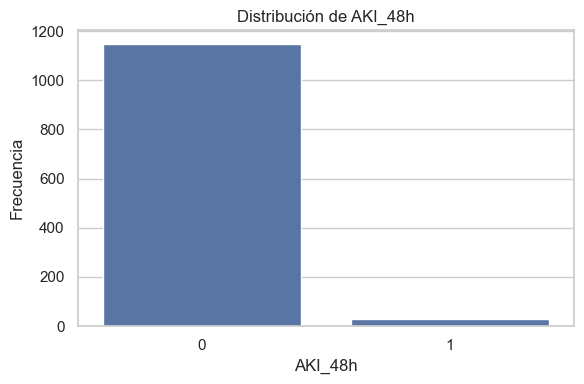

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(x="AKI_48h", data=df)
plt.title("Distribución de AKI_48h")
plt.xlabel("AKI_48h")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_01_target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### 14. Estadística de las variables descriptivas
Se utilizó `describe()` sobre las variables numéricas para obtener:
- media
- desviación estándar
- mínimo
- máximo
- percentiles

Este paso permitió obtener una visión global de la distribución de las variables continuas y detectar posibles valores extremos o rangos anómalos.


In [25]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
EdadAproxIngreso,1175.0,71.82383,19.510285,1.0,63.0,76.0,86.0,110.0
Creatinina_mg_dL,1170.0,1.072846,0.719258,0.0,0.7,0.885,1.18,9.55
Urea_mg_dL,41.0,36.643902,13.635176,16.7,28.5,34.6,40.0,96.0
Potasio_mmol_L,1122.0,4.289929,0.624424,0.0,3.9,4.2,4.6,7.9
Sodio_mmol_L,1126.0,138.693872,6.664357,0.0,137.0,139.0,141.0,169.0
BaselineCreatinina,1173.0,1.072805,0.718568,0.0,0.7,0.88,1.18,9.55
MaxCreatinina48h,678.0,1.071401,0.690316,0.19,0.6725,0.86,1.1975,6.77


### 15. Revisión de rangos mínimos y máximos
Se inspeccionaron explícitamente los valores mínimos y máximos de las variables numéricas para detectar:
- posibles errores de registro
- valores fuera de rango
- valores clínicamente plausibles pero extremos

Este análisis es especialmente importante en contexto clínico, donde un valor extremo no siempre implica error, sino que puede reflejar una situación real de gravedad.


In [26]:
for col in numeric_cols:
    print(f"{col}: min = {df[col].min()}, max = {df[col].max()}")

EdadAproxIngreso: min = 1, max = 110
Creatinina_mg_dL: min = 0.0, max = 9.55
Urea_mg_dL: min = 16.7, max = 96.0
Potasio_mmol_L: min = 0.0, max = 7.9
Sodio_mmol_L: min = 0.0, max = 169.0
BaselineCreatinina: min = 0.0, max = 9.55
MaxCreatinina48h: min = 0.19, max = 6.77


### 16. Histogramas de variables numéricas
Se generaron histogramas para todas las variables numéricas con el objetivo de:
- visualizar la forma de sus distribuciones
- detectar asimetrías
- identificar concentraciones de valores
- observar posibles colas largas o valores extremos

Esto ayudó a comprender mejor el comportamiento de las variables analíticas antes del modelado.


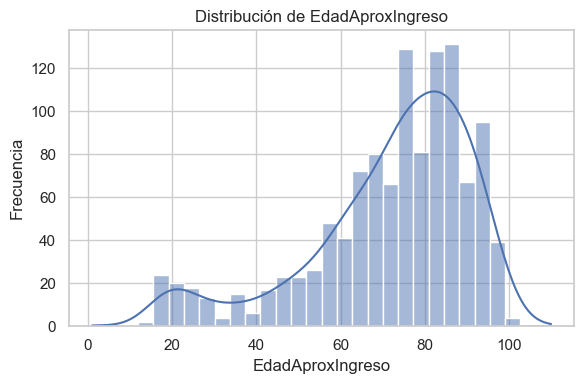

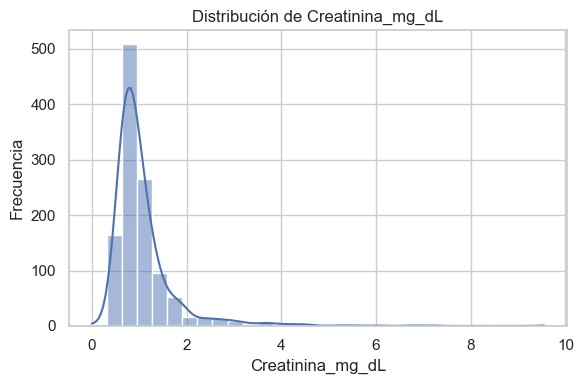

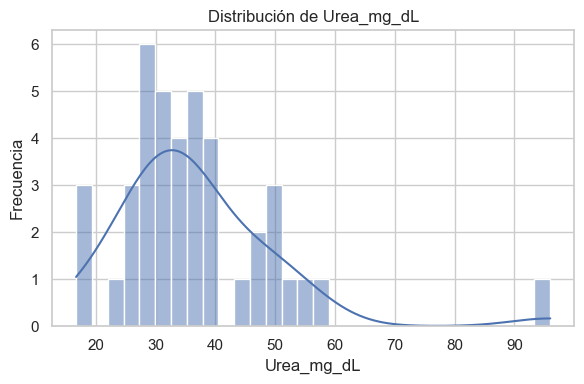

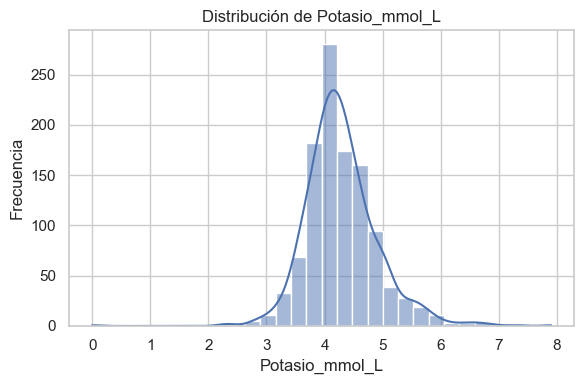

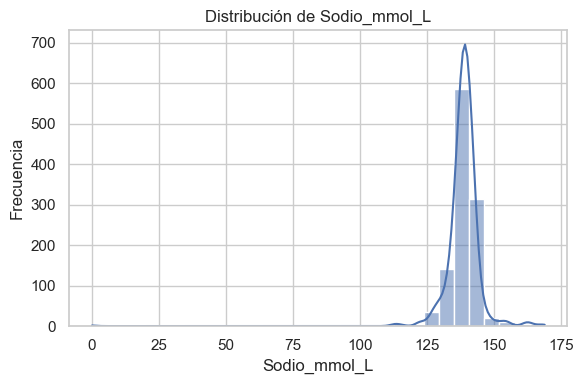

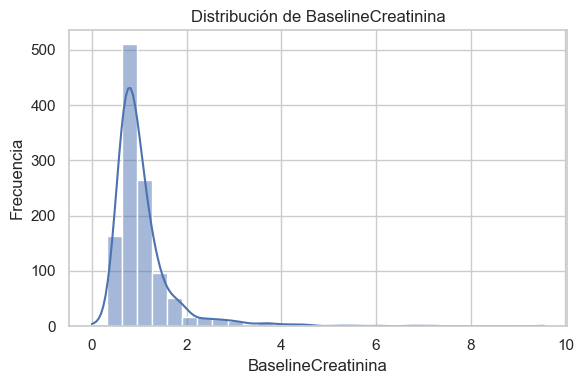

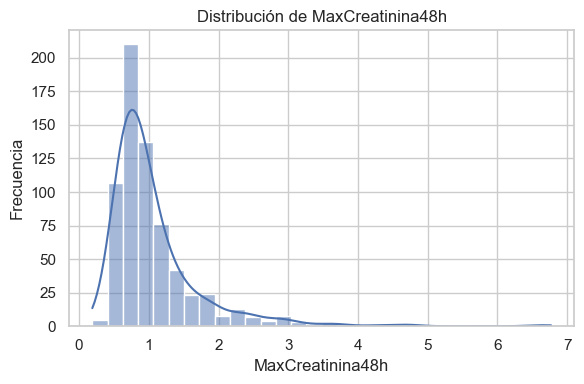

In [27]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/fig_hist_{col}.png", dpi=300, bbox_inches="tight")
    plt.show()

### 17. Boxplots de variables numéricas
Se generaron diagramas de caja para identificar visualmente:
- dispersión
- mediana
- posibles outliers

Este paso complementó a los histogramas y permitió observar de forma rápida la presencia de valores alejados del centro de la distribución.

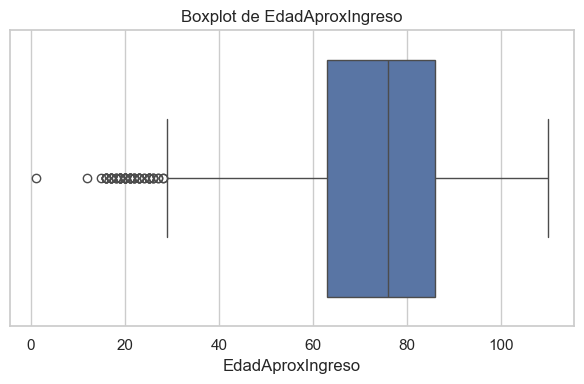

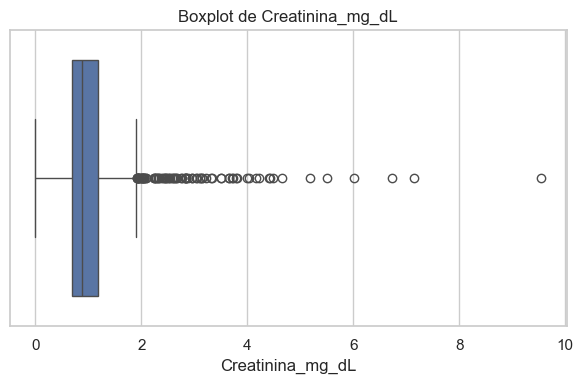

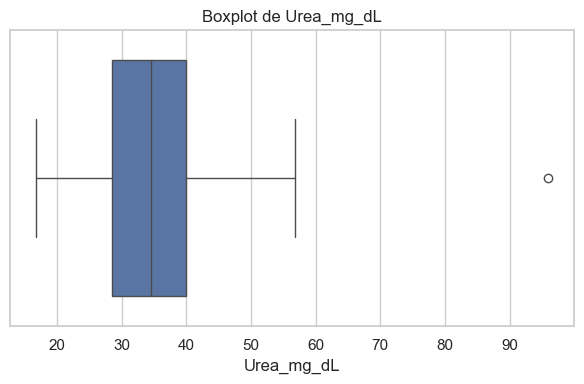

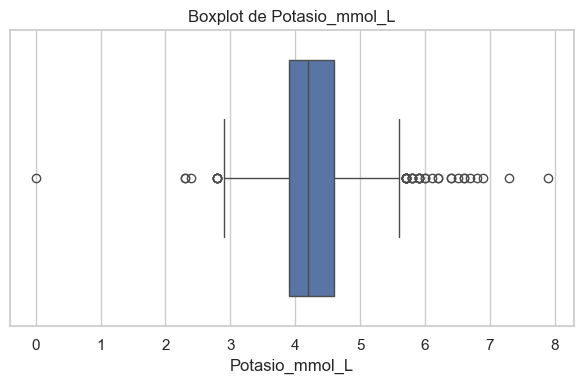

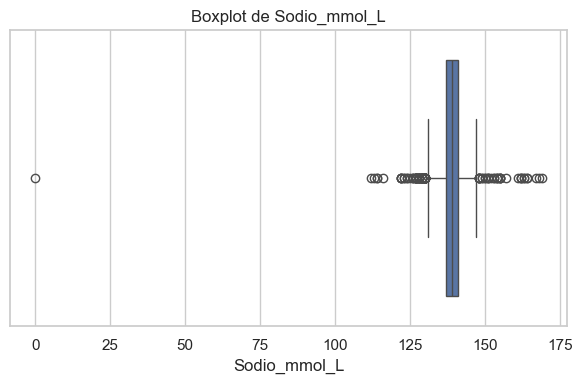

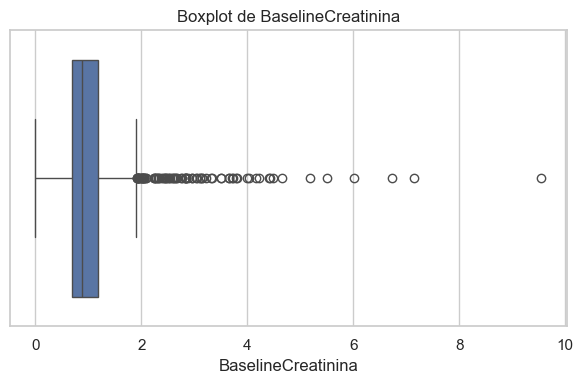

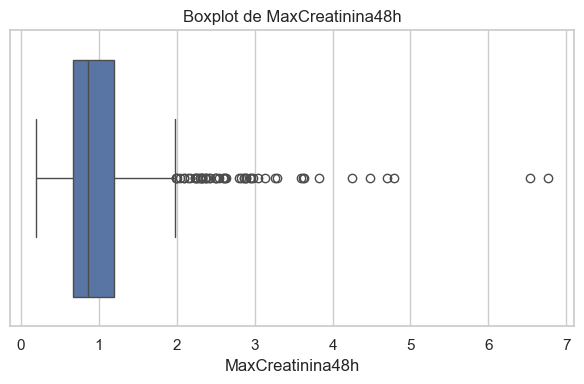

In [28]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/fig_box_{col}.png", dpi=300, bbox_inches="tight")
    plt.show()

### 18. Variables numéricas según la variable objetivo
Se representaron boxplots de las variables numéricas estratificados por `AKI_48h`.

El objetivo fue explorar si existían diferencias visuales preliminares entre:
- pacientes que desarrollaron AKI
- pacientes que no lo desarrollaron

Este análisis no se interpretó como evidencia causal, sino como una primera exploración descriptiva útil para el modelado posterior.

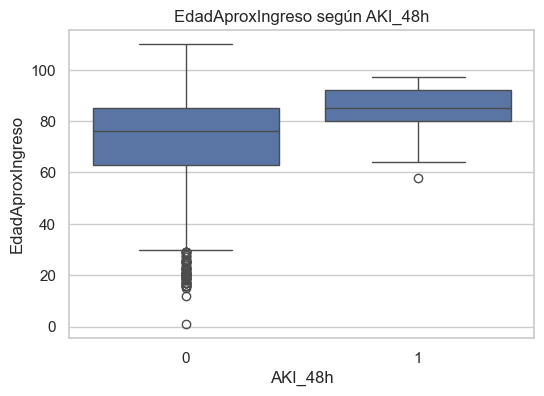

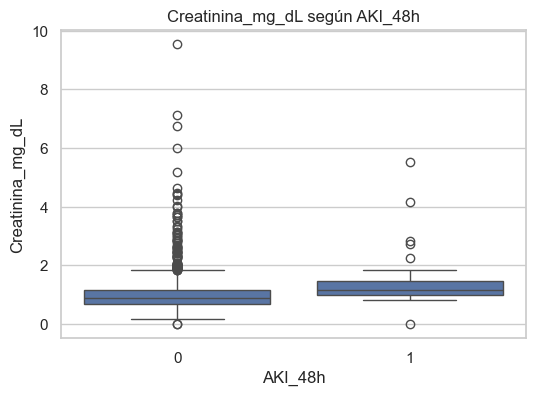

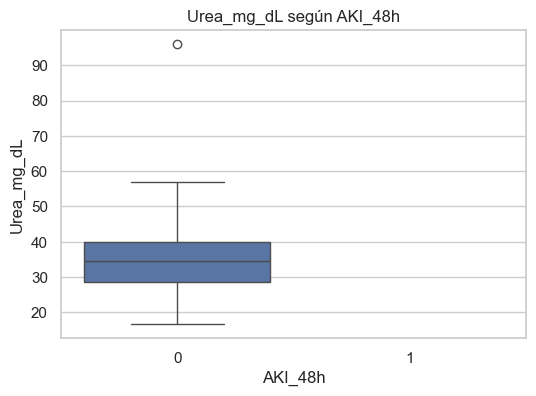

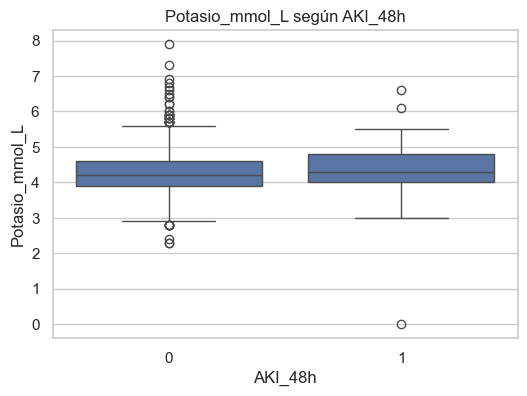

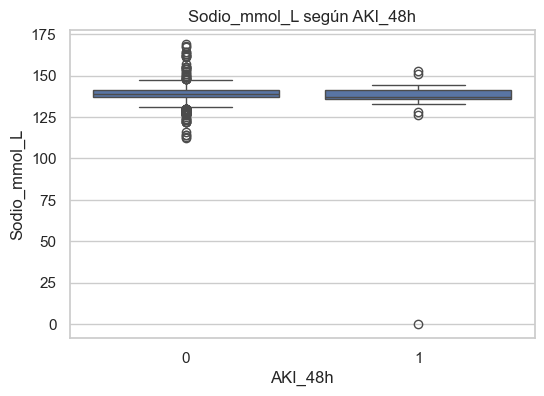

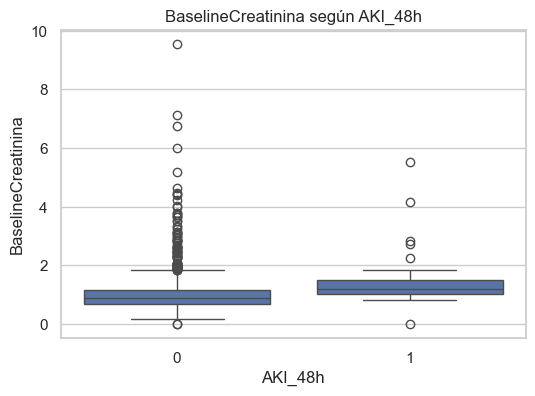

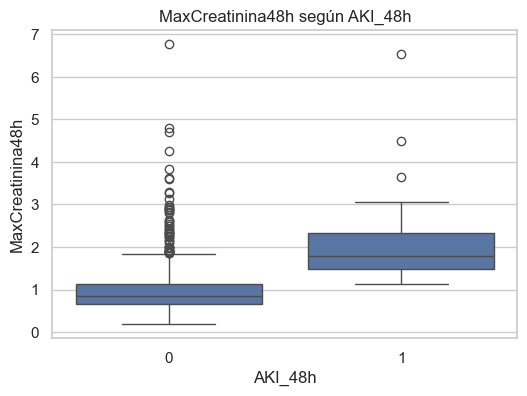

In [75]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="AKI_48h", y=col, data=df)
    plt.title(f"{col} según AKI_48h")
    plt.xlabel("AKI_48h")
    plt.ylabel(col)
    plt.show()

### 19. Correlación entre variables numéricas
Se calculó y representó una matriz de correlación entre variables numéricas y la variable objetivo.

Esto permitió:
- explorar relaciones lineales generales entre variables
- detectar posibles asociaciones entre biomarcadores
- identificar posibles solapamientos entre variables clínicas relacionadas

No obstante, se interpretó con cautela, dado que la correlación no implica causalidad ni sustituye el análisis predictivo formal

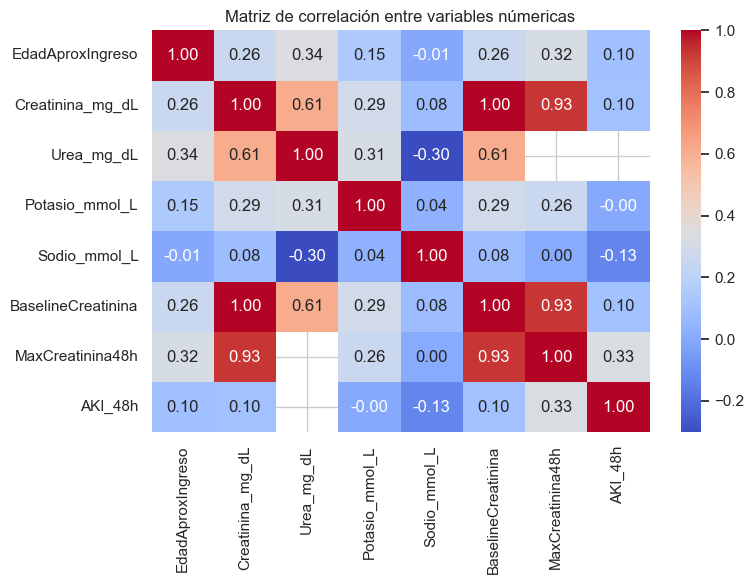

In [29]:
corr = df[numeric_cols + ["AKI_48h"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre variables númericas")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_02_corr_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

### 20. Conclusiones de la exploración inicial

- El dataset quedó correctamente cargado y alineado con la query SQL maestra.
- El dataset contiene 1175 ingresos hospitalarios, con una fila por ingreso.
- No se detectaron duplicados completos ni duplicados en `IdIngreso`, por lo que se confirma la unicidad de la unidad de análisis.
- La variable objetivo `AKI_48h` presenta un fuerte desbalanceo, con 29 casos positivos frente a 1146 negativos.
- Las variables farmacológicas están correctamente codificadas como binarias.
- La variable `Sexo` presenta dos categorías codificadas como 1 y 2, que deberán documentarse y recodificarse en la fase de limpieza.
- Las variables analíticas estaban almacenadas como texto con coma decimal, por lo que fue necesaria una conversión manual a tipo numérico.
- `Urea_mg_dL` y presenta una proporción extremadamente alta de valores faltantes, por lo que será evaluada críticamente en la fase de limpieza y selección de variables.
- `MaxCreatinina48h` presenta un número elevado de valores faltantes, lo cual es coherente con que no todos los ingresos dispongan de una determinación posterior dentro de las 48 horas.
- A partir de esta exploración, el siguiente paso será la limpieza de datos, la selección de variables relevantes y la preparación del dataset final para modelado.